# <center> PROJECT-3. EDA + Feature Engineering. Соревнование на Kaggle

___

## Постановка проблемы

Представьте, что вы работаете датасаентистом в компании Booking. Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. Одним из способов нахождения таких отелей является построение модели, которая предсказывает рейтинг отеля. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель играет нечестно, и его стоит проверить.

___

## Загрузка данных

In [151]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели 
#from sklearn import preprocessing # инструмент для нормализации 
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook")
sns.set_palette("Set2") 

In [152]:
# Загружаем датасет
df = pd.read_csv('data/hotels.csv')
print(df.shape)
df.head()

(386803, 17)


,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


___

## Описательный анализ данных

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

В датасете 326803 строк  
В строках с географической широтой и долготой ('lat', 'lng') содержатся пропуски (2448 строк)

In [154]:
print('Количество дубликатов: {}'.format(df[df.duplicated()].shape[0]))

# Удаляем дубликаты:
df = df.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(df.shape))

Количество дубликатов: 307
Размер таблицы после удаления дубликатов: (386496, 17)


In [155]:
df[['hotel_name', 'hotel_address']].nunique()

hotel_name       1492
hotel_address    1493
dtype: int64

Датасет содержит данные о 1492 отелях, у пары отелей повторяется название

**Рассмотрим распределение оценки отелей**

Средняя оценка рецензентов: 8.397298549014739
Средний балл отелей за год: 8.397420930617653


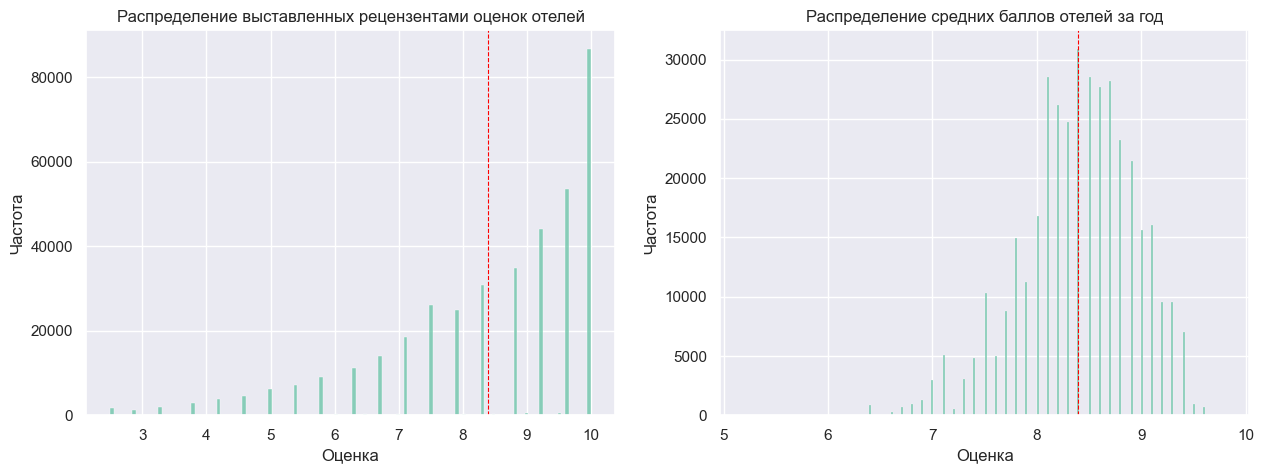

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['reviewer_score'], ax=axes[0])
axes[0].set(xlabel='Оценка', ylabel='Частота')
axes[0].set_title('Распределение выставленных рецензентами оценок отелей')
axes[0].axvline(df['reviewer_score'].mean(), color='red', linestyle='--', linewidth=0.8)
sns.histplot(df['average_score'], ax=axes[1])
axes[1].set(xlabel='Оценка', ylabel='Частота')
axes[1].set_title('Распределение средних баллов отелей за год')
axes[1].axvline(df['average_score'].mean(), color='red', linestyle='--', linewidth=0.8)
print('Средняя оценка рецензентов: {}'.format(df['reviewer_score'].mean()))
print('Средний балл отелей за год: {}'.format(df['average_score'].mean()))
plt.show()

Видим, что количество оценкок нелинейно увеличивается с увеличением значения оценки. Средняя оценка и средний балл равны примерно 8.4

**Построим графики распределения оставшихся числовых признаков**  
(за исключением географических широты и долготы. Кроме того не будем исользовать 'additional_number_of_scoring', причины указаны ниже)

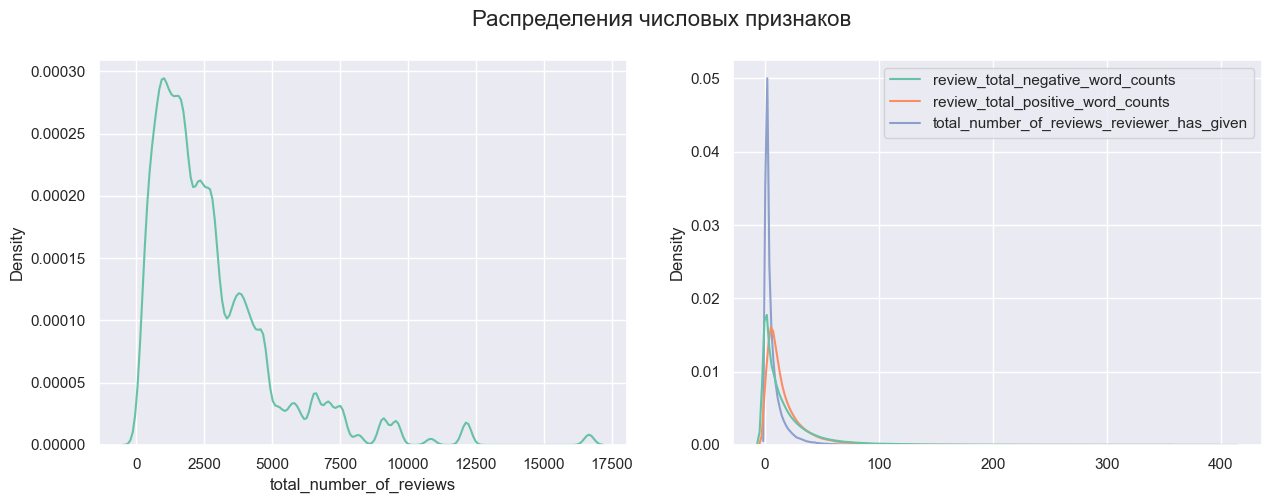

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(
    df['total_number_of_reviews'], 
    ax=axes[0]
    )
sns.kdeplot(
    df[['review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given']],
    ax=axes[1])
fig.suptitle('Распределения числовых признаков', fontsize=16)
plt.show()

Из графиков помимо распределений видно, что у признаков разный порядок. Возможно необходимо будет провести стандартизацию

**Проведем корреляционный анализ**

<Axes: >

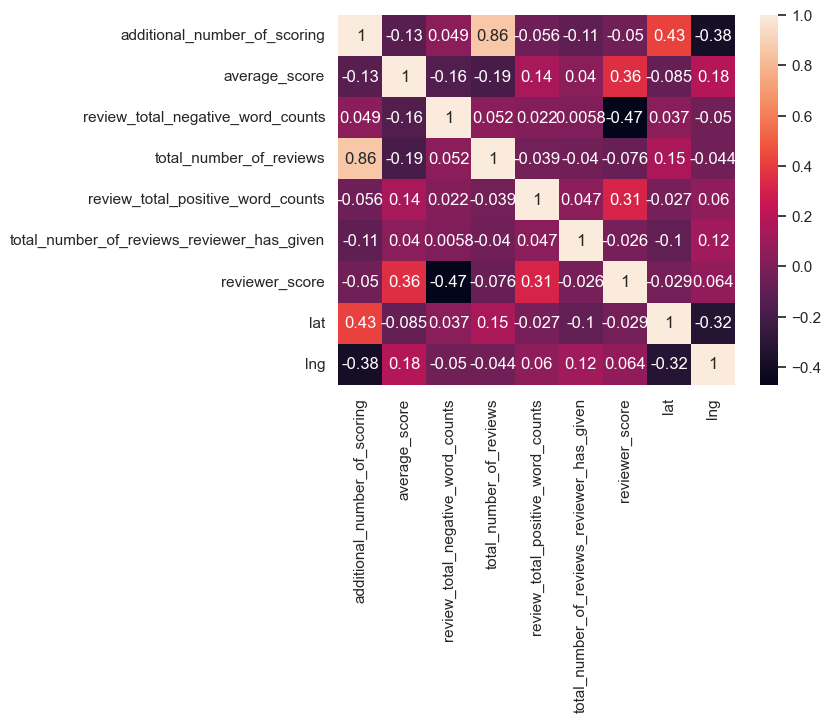

In [158]:
sns.heatmap(df.corr(method='spearman', numeric_only=True), annot=True)

Признаки additional_number_of_scoring и total_number_of_review имеют сильную корреляционную связь

In [159]:
# Удалим признак additional_number_of_scoring для избежания мультиколлинеарности
df.drop(['additional_number_of_scoring'], axis=1, inplace=True)


___

## Проектирование признаков

Проанализируем названия стран, в которых находятся отели. Создадим на основе этих названий dummy-признаки

In [160]:
def get_country(hotel_adress):
    """Функция обрабатывает адресс отеля и на его основе
    возвращает название страны. Для каждой из стран, кроме Великобритании
    берется последнее значение из строки адреса, для Великобритании - два значения
    
    Args:
        hotel_adress (_str_): адрес отеля, в котором название страны указано в конце

    Returns:
        _str_: название страны
    """
    word_list = hotel_adress.split()
    country_name = word_list[-1]
    if country_name == 'Kingdom':
        country_name = ' '.join(word_list[-2:])
    return country_name

df['country'] = df['hotel_address'].apply(get_country)
df['country'].value_counts()

country
United Kingdom    196773
Spain              45132
France             44528
Netherlands        43004
Austria            29177
Italy              27882
Name: count, dtype: int64

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386496 non-null  object 
 1   review_date                                 386496 non-null  object 
 2   average_score                               386496 non-null  float64
 3   hotel_name                                  386496 non-null  object 
 4   reviewer_nationality                        386496 non-null  object 
 5   negative_review                             386496 non-null  object 
 6   review_total_negative_word_counts           386496 non-null  int64  
 7   total_number_of_reviews                     386496 non-null  int64  
 8   positive_review                             386496 non-null  object 
 9   review_total_positive_word_counts           386496 non-null  int64  
 10  t

В таблице представлены данные отелей, которые расположены всего в шести странах. Не составит труда определить находится ли отель в столице страны.

In [162]:
def is_capital(hotel_adress):
    """Функция проверят содержится ли в адресе название города соответствующее названию столицы.
    Возвращает True или False

    Args:
        hotel_adress (_str_): адрес отеля
    """
    # Инициализируем список с названиями столиц стран из набора данных
    capitals_name = ['London', 'Madrid', 'Paris', 'Amsterdam', 'Vienna', 'Rome']
    # Проверяем, есть ли название одной из столиц в адресе отеля
    for name in capitals_name:
        if name in hotel_adress:
            return True
    return False

df['is_capital'] = df['hotel_address'].apply(is_capital)

# Удалим признак hotel_address
df.drop(['hotel_address'], axis=1, inplace=True)


Создадим признак, показывающий разницу во времени (в днях) с первого отзыва до текущего

In [163]:
# Преобразуем к review_date datetame
df['review_date'] = pd.to_datetime(df['review_date'])
# Выберем наименьшую дату, которую примем за первую
min_review_date = df['review_date'].min()
df['delta_review_date'] = (df['review_date'] - min_review_date).dt.days

# Удалим признак review_date
df.drop(['review_date'], axis=1, inplace=True)


In [164]:
# Преобразуем признак tags к списку
df['tags'] = df['tags'].apply(lambda x: eval(x))
# Найдем количество уникальных тегов
tags_list = []
for tags in df['tags']:
    tags_list += tags
unique_tags = set(tags_list)
    
print('Количество уникальных тегов: {}'.format(len(unique_tags)))
# Посмотрим какие уникальные теги есть в наборе данных:
print(unique_tags)

Количество уникальных тегов: 2368
{' Business Double or Twin Room Facing the Sea ', ' Duplex Twin Room ', ' Premium Double or Twin Room with View and Terrace ', ' Family Room Two Connecting Rooms VIP Welcome for Kids ', ' Triple Room Luxury XXL King Size Bed ', ' Executive Junior Suite ', ' Small Double Room with Terrace ', ' Superior Queen Room with Sofa ', ' Comfort Twin Double Room ', ' Triple Room 2 Adults 1 Child ', ' Deluxe Plus Double Room ', ' Duplex Double Room ', ' Accessible Studio Suite ', ' King One Bedroom Suite with Lounge Access ', ' Comfort King or Twin Room ', ' Green Park Suite ', ' Executive Double Room with Turkish Bath ', ' Studio Double Family ', ' Premium Triple Room ', ' Superior Double or Twin Room with Extra Bed 2 Adults 1 Child ', ' Privilege Double Room with Terrace ', ' Suite Canal View ', ' Queen Superior Room ', ' Park Deluxe View Twin ', ' Twin or Double Room with Terrace ', ' Standard Double or Twin Room with Extra Bed 3 Adults ', ' Superior Apartment 

Во многих тегах есть информация, которая поможет разбить отели на группы:
1. По типу размещения
2. По комфорту
3. По количесвту ночей

При создании признаков будем использовать только самые популярные типы номеров, чтобы не перегружать модель лишними признаками.

In [165]:
# Для удобного поиска слов в ячейках с тегами, объединим теги нижними подчеркиваниями
# 1. Объединим элементы списка
# 2. Удалим пробелы слева и справа
# 3. Заменим двойные пробелы нижним подчеркиванием
# 4. Заменим пробел нижним подчеркиванием
df['tags'] = df['tags'].apply(lambda x: ''.join(x).strip().replace('  ', '_').replace(' ', '_'))

# 1.
# Создадим список с количеством комнат
type_of_placement = ['Single', 'Double', 'Twin', 'Triple']
# Так как в одном отеле могут быть разные номера с разными количествами комнат,
# в строке может быть указано сразу два тега, характеризующих тип размещения.
# Создадим признак для каждого из четырех типов комнат:
for tag in type_of_placement:
    df[f'tag_{tag}'] = df['tags'].apply(lambda x: 1 if tag in x else 0)
    
# 2.
# Создадим список с типом номеров по уровню комфорта
comfort_level = ['Standart', 'Junior Suite', 'Suite', 'Deluxe', 'Duplex', 'Studio']
# Аналогично в строке могут указываться сразу несколько типов номеров
# Создадим признаки
for tag in comfort_level:
    # Так как Suite содержится в двух типах, при создании признака проверим
    # что в строке нет 'Junior'
    if tag == 'Suite':
        df['tag_Suite'] = df['tags'].apply(lambda x: 1 if tag in x and 'Junior' not in x else 0)
    # Для единообразия (чтобы не было пробела между словами) название для признака tag_Junior_Suite введем вручную
    elif tag == 'Junior Suite':
        df[f'tag_Junior_Suite'] = df['tags'].apply(lambda x: 1 if tag in x else 0)
    else:
        df[f'tag_{tag}'] = df['tags'].apply(lambda x: 1 if tag in x else 0)

# 3.      
# Создадим признаки для количества ночей (1, 2, 3, >3)
def get_num_of_nights(tags):
    '''Функция возвращает количество ночей (от 1 до 3, или >3), если это указано в ячейке'''
    if 'Stayed' in tags:
        # Создадим переменную с количеством ночей
        number_of_nights = int(tags[tags.index('Stayed') + 7])
        if number_of_nights < 4:
            return str(number_of_nights)
        else:
            return '>3'
        
df['Stayed'] = df['tags'].apply(get_num_of_nights)

In [191]:
df[df['tag_Single']==1]['reviewer_score'].mean()

8.012454989394762

___

## Преобразование признаков

In [167]:
# Создадим dummy-признаки на основе названия стран
df = pd.get_dummies(df, columns=['country'])

In [168]:
# Преобразуем признак Stayed с помощью метода get_dummies
df = pd.get_dummies(df, columns=['Stayed'])

Преобразуем признак days_since_review в числовой вид

In [169]:
df['days_since_review'] = df['days_since_review'].apply(lambda x: int(x.split()[0]))

Заполним пустые значения в признаках:

In [170]:
df.fillna({'lat': df['lat'].median(), 'lng': df['lng'].median()}, inplace=True)

Удалим нечисловые признаки

In [171]:
df.drop(['hotel_name', 'reviewer_nationality', 'negative_review', 'positive_review', 'tags'], axis=1, inplace=True)

Для удобства дальнейшего статистического анализа категорируем признаки 'total_number_of_reviews' и 'delta_review_date'

In [172]:
def get_category_total_number(number_of_reviews):
    """Функция принимает значение параметра 'total_number_of_reviews_cat'
    и возвращает категорию (от 1 до 3) в зависимости от принятого значения
    """
    if number_of_reviews < 1000:
        return 1
    elif 1000 <= number_of_reviews <= 5000:
        return 2
    else:
        return 3

   
def get_category_delta_review_date(delta_review_date):
    """Функция принимает значение параметра 'delta_review_date'
    и возвращает категорию (от 1 до 3) в зависимости от принятого значения
    """
    if delta_review_date < 250:
        return 1
    elif 250 <= delta_review_date <= 500:
        return 2
    else:
        return 3        
    
    
df['total_number_of_reviews'] = df['total_number_of_reviews'].apply(get_category_total_number)
df['delta_review_date'] = df['delta_review_date'].apply(get_category_delta_review_date)

____

## Статистический анализ

In [173]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [174]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

Часть признаков уже была удалена в ходе выполнения проекта.  
Произведем анализ и удалим признаки, статистически не влияющие на предсказываемый признак

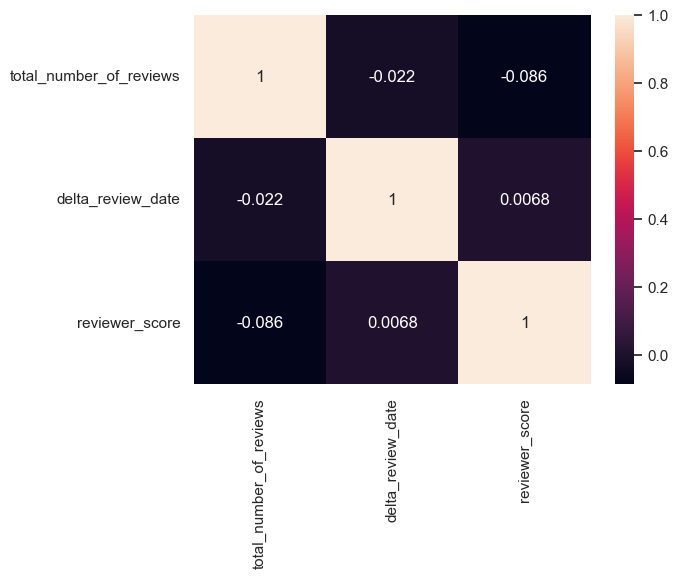

In [175]:
col_names = ['total_number_of_reviews', 'delta_review_date', 'reviewer_score']

df_corr = df[col_names].corr('spearman')

# Построим тепловую карту корреляции чтобы понять, как связаны признаки с оценкой
sns.heatmap(df_corr, annot=True)
plt.show()

Признаки очень слабо коррелируют с оценкой рецензента. Проверим действительно ли данные признаки не влияют на результат

*Нулевая гипотеза* ($H_0$): оценка одинакова для разного количества отзывов (нет взаимосвязи).

*Альтернативная гипотеза* ($H_1$): оценка отличается в зависимотсти от количества отзывов (есть взаимосвязь).

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Пол»? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [176]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(df['reviewer_score'], df['total_number_of_reviews'])
cross_table.head()

total_number_of_reviews,1,2,3
reviewer_score,,,
2.5,315,1031,282
2.9,205,767,235
3.0,3,15,7
3.1,0,6,0
3.3,360,1312,386


In [177]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Аналогично проверим признак 'delta_review_date'

In [178]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(df['reviewer_score'], df['delta_review_date'])
cross_table.head()

delta_review_date,1,2,3
reviewer_score,,,
2.5,447,621,560
2.9,329,437,441
3.0,8,7,10
3.1,4,1,1
3.3,590,735,733


In [179]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Судя по тестам, не стоит удалять данные признаки, связь прослеживается

In [180]:
df.head()

,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,is_capital,...,country_Austria,country_France,country_Italy,country_Netherlands,country_Spain,country_United Kingdom,Stayed_1,Stayed_2,Stayed_3,Stayed_>3
0,8.4,3,2,4,7,10.0,531,51.507894,-0.143671,True,...,False,False,False,False,False,True,False,True,False,False
1,8.3,3,2,2,14,6.3,203,51.521009,-0.123097,True,...,False,False,False,False,False,True,True,False,False,False
2,8.9,6,1,0,14,7.5,289,48.845377,2.325643,True,...,False,True,False,False,False,False,False,False,True,False
3,7.5,0,1,11,8,10.0,681,48.888697,2.394540,True,...,False,True,False,False,False,False,True,False,False,False
4,8.5,4,3,20,10,9.6,516,52.385601,4.847060,True,...,False,False,False,True,False,False,False,False,False,True


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 31 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               386496 non-null  float64
 1   review_total_negative_word_counts           386496 non-null  int64  
 2   total_number_of_reviews                     386496 non-null  int64  
 3   review_total_positive_word_counts           386496 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 5   reviewer_score                              386496 non-null  float64
 6   days_since_review                           386496 non-null  int64  
 7   lat                                         386496 non-null  float64
 8   lng                                         386496 non-null  float64
 9   is_capital                                  386496 non-null  bool   
 10  d

___

## Построение модели

In [182]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х — данные с информацией об отелях, у — целевая переменная (рейтинги отелей)  
X = df.drop(['reviewer_score'], axis = 1)  
y = df['reviewer_score']  
      
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  
    
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" — для тестирования.  
# Для тестирования мы будем использовать 25 % от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [183]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 30 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               386496 non-null  float64
 1   review_total_negative_word_counts           386496 non-null  int64  
 2   total_number_of_reviews                     386496 non-null  int64  
 3   review_total_positive_word_counts           386496 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 5   days_since_review                           386496 non-null  int64  
 6   lat                                         386496 non-null  float64
 7   lng                                         386496 non-null  float64
 8   is_capital                                  386496 non-null  bool   
 9   delta_review_date                           386496 non-null  int64  
 10  t

In [184]:
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)

In [185]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test) и смотрим, насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений в отношении фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.1375084769783374


In [193]:
predict_submission = model.predict(test_data)

array([8.898, 9.566, 7.398, ..., 7.128, 8.407, 9.08 ])